# BO-Guided Center Adaptation with Paper-Inspired DORAEMON (Gym surrogate -> TinySim target)

This variant adapts your pipeline closer to the DORAEMON paper mechanics:
- bounded **Beta** distribution over dynamics params
- **entropy maximization** under a success constraint
- **KL trust-region** between consecutive distribution updates
- **importance-sampling** estimate of in-distribution success

It keeps your BO ask/tell target optimization and warm-start training workflow.

## 1) Imports and Global Setup

In [35]:
from __future__ import annotations

import csv
import json
import os
import random
import time
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.special import betaln, digamma

from tinysim.mountain_car import MountainCarEnv

In [36]:
# BO dependency check (chosen engine: scikit-optimize GP ask/tell)
try:
    from skopt import Optimizer
    from skopt.space import Real
except Exception as exc:
    raise ImportError(
        "scikit-optimize is required. Install with: `pip install scikit-optimize`"
    ) from exc

print('skopt imported successfully')


skopt imported successfully


## 2) Config (edit this cell)

- `TARGET_PARAMS` is used **only** for TinySim target evaluation.
- BO never gets direct access to target params beyond scalar target eval score.


In [37]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

PROJECT_DIR = Path('/home/buchkeva/IdeaTesting/TinySim')
RUNS_ROOT = PROJECT_DIR / 'runs'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

WARMSTART_CHECKPOINT = PROJECT_DIR / 'mountain_car_saved' / 'mountain_car_dqn.pt'

DR_BOUNDS = {
    'force': (0.0003, 0.0030),
    'gravity': (0.0010, 0.0062),
}
EDGE_DR_BOUNDS = {
    'force': (0.0007, 0.0018),
    'gravity': (0.0030, 0.0059),
}

MU0 = np.array([0.0010, 0.0025], dtype=np.float32)
MU0_EDGE = np.array([
    float(np.clip(MU0[0], EDGE_DR_BOUNDS['force'][0], EDGE_DR_BOUNDS['force'][1])),
    float(np.clip(MU0[1], EDGE_DR_BOUNDS['gravity'][0], EDGE_DR_BOUNDS['gravity'][1])),
], dtype=np.float32)

TAU_STEPS = 360
ALPHA_TARGET = 0.60
KL_MAX = 0.04
C_INIT = np.array([18.0, 18.0], dtype=np.float32)
C_MIN = np.array([2.2, 2.2], dtype=np.float32)
C_MAX = np.array([220.0, 220.0], dtype=np.float32)
CANDIDATES_PER_UPDATE = 300
MEAN_PERTURB_STD = 0.06
LOGC_PERTURB_STD = 0.20
MIN_WEIGHT_LOG = -20.0
MAX_WEIGHT_LOG = 20.0

# BO/DR role separation controls
FREEZE_DORAEMON_MEAN = True   # BO controls center (mean); DORAEMON controls spread only
CONC_INIT_MODE = 'reset'      # one of: 'reset', 'carry', 'blend'
CONC_BLEND = 0.5              # used only when CONC_INIT_MODE='blend'

TARGET_PARAMS = {
    'force': 0.0010,
    'gravity': 0.0050,
}

SMOKE_CFG = dict(T=3, blocks=5, episodes_per_block=4, B_r=5)
PROTO_CFG = dict(T=12, blocks=20, episodes_per_block=6, B_r=12)
EDGE_CFG = dict(T=20, blocks=30, episodes_per_block=6, B_r=20)

print('Warmstart checkpoint:', WARMSTART_CHECKPOINT)
print('Target params (eval only):', TARGET_PARAMS)
print('MU0_EDGE:', MU0_EDGE.tolist())
print('FREEZE_DORAEMON_MEAN:', FREEZE_DORAEMON_MEAN)
print('CONC_INIT_MODE:', CONC_INIT_MODE)

DEVICE: cuda
Warmstart checkpoint: /home/buchkeva/IdeaTesting/TinySim/mountain_car_saved/mountain_car_dqn.pt
Target params (eval only): {'force': 0.001, 'gravity': 0.005}
MU0_EDGE: [0.0010000000474974513, 0.003000000026077032]
FREEZE_DORAEMON_MEAN: True
CONC_INIT_MODE: reset


## 3) DQN Components (MountainCar)

In [38]:
class ReplayBuffer:
    def __init__(self, capacity: int = 10000):
        self.capacity = int(capacity)
        self.buffer = []
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        item = (
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            float(done),
        )
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int, device: str):
        idx = np.random.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        s, a, r, ns, d = zip(*batch)
        states = torch.tensor(np.stack(s), dtype=torch.float32, device=device)
        actions = torch.tensor(a, dtype=torch.long, device=device)
        rewards = torch.tensor(r, dtype=torch.float32, device=device)
        next_states = torch.tensor(np.stack(ns), dtype=torch.float32, device=device)
        dones = torch.tensor(d, dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_dim: int = 2, n_actions: int = 3, hidden_dim: int = 128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


@dataclass
class DQNConfig:
    state_dim: int = 2
    n_actions: int = 3
    hidden_dim: int = 128
    lr: float = 1e-3
    gamma: float = 0.99
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.995
    buffer_capacity: int = 10000
    batch_size: int = 64
    target_update_freq: int = 10


class DQNAgent:
    def __init__(self, cfg: DQNConfig, device: str = 'cpu'):
        self.cfg = cfg
        self.device = device

        self.policy_net = QNetwork(cfg.state_dim, cfg.n_actions, cfg.hidden_dim).to(device)
        self.target_net = QNetwork(cfg.state_dim, cfg.n_actions, cfg.hidden_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.lr)
        self.memory = ReplayBuffer(cfg.buffer_capacity)

        self.epsilon = cfg.epsilon_start
        self.training_losses = []
        self._episode_counter = 0

    def act(self, state: np.ndarray, training: bool = True) -> int:
        if training and random.random() < self.epsilon:
            return random.randrange(self.cfg.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q = self.policy_net(s)
            return int(q.argmax(dim=1).item())

    def store(self, s, a, r, ns, done):
        self.memory.push(s, a, r, ns, done)

    def learn_step(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        s, a, r, ns, d = self.memory.sample(self.cfg.batch_size, self.device)

        q = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            nq = self.target_net(ns).max(dim=1)[0]
            target = r + self.cfg.gamma * nq * (1.0 - d)

        loss = nn.MSELoss()(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        self.training_losses.append(float(loss.item()))
        return float(loss.item())

    def end_episode(self):
        self._episode_counter += 1
        self.epsilon = max(self.cfg.epsilon_end, self.epsilon * self.cfg.epsilon_decay)
        if (self._episode_counter % self.cfg.target_update_freq) == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def state_payload(self) -> dict[str, Any]:
        return {
            'policy_state_dict': self.policy_net.state_dict(),
            'target_state_dict': self.target_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'training_losses': self.training_losses,
            'hparams': vars(self.cfg),
        }

    def load_payload(self, payload: dict[str, Any]):
        self.policy_net.load_state_dict(payload['policy_state_dict'])
        self.target_net.load_state_dict(payload.get('target_state_dict', payload['policy_state_dict']))
        if 'optimizer_state_dict' in payload:
            self.optimizer.load_state_dict(payload['optimizer_state_dict'])
        self.epsilon = float(payload.get('epsilon', self.cfg.epsilon_end))
        self.training_losses = list(payload.get('training_losses', []))


## 4) Warm-start and Checkpoint Helpers

In [39]:
def make_agent_from_hparams(hparams: dict | None, device: str = DEVICE) -> DQNAgent:
    if hparams is None:
        cfg = DQNConfig()
    else:
        cfg = DQNConfig(**{k: v for k, v in hparams.items() if k in DQNConfig.__annotations__})
    return DQNAgent(cfg=cfg, device=device)


def load_warmstart_agent(checkpoint_path: str | Path, device: str = DEVICE) -> DQNAgent:
    payload = torch.load(str(checkpoint_path), map_location=device)
    hparams = payload.get('hparams')
    agent = make_agent_from_hparams(hparams, device=device)
    agent.load_payload(payload)
    return agent


def save_agent_checkpoint(agent: DQNAgent, path: str | Path, extra: dict | None = None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = agent.state_payload()
    payload['extra'] = extra or {}
    torch.save(payload, str(path))


def clone_agent(agent: DQNAgent) -> DQNAgent:
    cloned = make_agent_from_hparams(vars(agent.cfg), device=agent.device)
    cloned.load_payload(agent.state_payload())
    return cloned


## 5) Environment and Evaluation Helpers

In [40]:
def make_gym_env(force: float, gravity: float, seed: int | None = None):
    env = gym.make('MountainCar-v0')
    env.reset(seed=seed)
    env.unwrapped.force = float(force)
    env.unwrapped.gravity = float(gravity)
    return env


def normalize_params(force: float, gravity: float, bounds: dict) -> np.ndarray:
    zf = (float(force) - bounds['force'][0]) / (bounds['force'][1] - bounds['force'][0])
    zg = (float(gravity) - bounds['gravity'][0]) / (bounds['gravity'][1] - bounds['gravity'][0])
    return np.array([zf, zg], dtype=np.float64)


def denormalize_params(z: np.ndarray, bounds: dict) -> tuple[float, float]:
    force = bounds['force'][0] + float(z[0]) * (bounds['force'][1] - bounds['force'][0])
    gravity = bounds['gravity'][0] + float(z[1]) * (bounds['gravity'][1] - bounds['gravity'][0])
    return float(force), float(gravity)


def beta_from_mean_conc(mean: np.ndarray, conc: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    m = np.clip(np.asarray(mean, dtype=np.float64), 1e-4, 1.0 - 1e-4)
    c = np.clip(np.asarray(conc, dtype=np.float64), 2.0001, None)
    a = m * c
    b = (1.0 - m) * c
    return a, b


def mean_conc_from_beta(alpha: np.ndarray, beta: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    c = a + b
    m = a / np.clip(c, 1e-8, None)
    return m, c


def make_beta_dist_at_mu(mu: np.ndarray, conc: np.ndarray, bounds: dict) -> dict:
    mu = np.array([
        float(np.clip(mu[0], bounds['force'][0], bounds['force'][1])),
        float(np.clip(mu[1], bounds['gravity'][0], bounds['gravity'][1])),
    ], dtype=np.float64)
    z = normalize_params(mu[0], mu[1], bounds)
    a, b = beta_from_mean_conc(z, conc)
    return {'alpha': a, 'beta': b, 'bounds': bounds}


def beta_logpdf(z: np.ndarray, alpha: np.ndarray, beta: np.ndarray) -> np.ndarray:
    z = np.clip(np.asarray(z, dtype=np.float64), 1e-6, 1.0 - 1e-6)
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    return (a - 1.0) * np.log(z) + (b - 1.0) * np.log(1.0 - z) - betaln(a, b)


def beta_entropy(alpha: np.ndarray, beta: np.ndarray) -> np.ndarray:
    a = np.asarray(alpha, dtype=np.float64)
    b = np.asarray(beta, dtype=np.float64)
    return betaln(a, b) - (a - 1.0) * digamma(a) - (b - 1.0) * digamma(b) + (a + b - 2.0) * digamma(a + b)


def dist_entropy(dist: dict) -> float:
    h = beta_entropy(dist['alpha'], dist['beta'])
    s_force = np.log(dist['bounds']['force'][1] - dist['bounds']['force'][0])
    s_grav = np.log(dist['bounds']['gravity'][1] - dist['bounds']['gravity'][0])
    return float(np.sum(h) + s_force + s_grav)


def beta_kl(a0: np.ndarray, b0: np.ndarray, a1: np.ndarray, b1: np.ndarray) -> np.ndarray:
    return (
        betaln(a1, b1) - betaln(a0, b0)
        + (a0 - a1) * digamma(a0)
        + (b0 - b1) * digamma(b0)
        + (a1 + b1 - a0 - b0) * digamma(a0 + b0)
    )


def dist_kl(old: dict, new: dict) -> float:
    return float(np.sum(beta_kl(old['alpha'], old['beta'], new['alpha'], new['beta'])))


def sample_beta_params(dist: dict, rng: np.random.Generator):
    z = rng.beta(dist['alpha'], dist['beta'])
    z = np.clip(z, 1e-6, 1.0 - 1e-6)
    force, gravity = denormalize_params(z, dist['bounds'])
    return force, gravity, z.astype(np.float64)


def is_success_estimate(
    z_samples: np.ndarray,
    success: np.ndarray,
    old_dist: dict,
    new_dist: dict,
    min_log_w: float = -20.0,
    max_log_w: float = 20.0,
) -> float:
    if len(z_samples) == 0:
        return 0.0
    z = np.clip(np.asarray(z_samples, dtype=np.float64), 1e-6, 1.0 - 1e-6)
    s = np.asarray(success, dtype=np.float64)

    logp_old = np.sum(beta_logpdf(z, old_dist['alpha'], old_dist['beta']), axis=1)
    logp_new = np.sum(beta_logpdf(z, new_dist['alpha'], new_dist['beta']), axis=1)

    logw = np.clip(logp_new - logp_old, min_log_w, max_log_w)
    w = np.exp(logw - np.max(logw))
    w = w / np.clip(np.sum(w), 1e-12, None)
    return float(np.sum(w * s))


def doraemon_update_beta(
    old_dist: dict,
    z_samples: np.ndarray,
    success_samples: np.ndarray,
    alpha_target: float,
    kl_max: float,
    rng: np.random.Generator,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
    freeze_mean: bool = True,
):
    m_old, c_old = mean_conc_from_beta(old_dist['alpha'], old_dist['beta'])

    candidates = [(m_old.copy(), c_old.copy())]
    for _ in range(int(n_candidates)):
        if freeze_mean:
            m = m_old.copy()
        else:
            m = np.clip(m_old + rng.normal(0.0, mean_std, size=2), 1e-4, 1.0 - 1e-4)
        c = np.exp(np.log(np.clip(c_old, 1e-8, None)) + rng.normal(0.0, logc_std, size=2))
        c = np.clip(c, c_min, c_max)
        candidates.append((m, c))

    best_feasible = None
    backup = None

    for m, c in candidates:
        a_new, b_new = beta_from_mean_conc(m, c)
        cand = {'alpha': a_new, 'beta': b_new, 'bounds': old_dist['bounds']}

        kl = dist_kl(old_dist, cand)
        if kl > kl_max:
            continue

        g_hat = is_success_estimate(
            z_samples=z_samples,
            success=success_samples,
            old_dist=old_dist,
            new_dist=cand,
            min_log_w=min_log_w,
            max_log_w=max_log_w,
        )
        ent = dist_entropy(cand)

        if (backup is None) or (g_hat > backup['g_hat']) or (np.isclose(g_hat, backup['g_hat']) and ent > backup['entropy']):
            backup = {'dist': cand, 'g_hat': float(g_hat), 'entropy': float(ent), 'kl': float(kl), 'mode': 'backup_success'}

        if g_hat >= alpha_target:
            if (best_feasible is None) or (ent > best_feasible['entropy']):
                best_feasible = {'dist': cand, 'g_hat': float(g_hat), 'entropy': float(ent), 'kl': float(kl), 'mode': 'feasible_entropy'}

    if best_feasible is not None:
        return best_feasible['dist'], best_feasible
    if backup is not None:
        return backup['dist'], backup

    return old_dist, {'dist': old_dist, 'g_hat': 0.0, 'entropy': dist_entropy(old_dist), 'kl': 0.0, 'mode': 'no_candidate'}


def target_eval_tinysim_detailed(
    agent: DQNAgent,
    n_eval_target: int,
    max_steps: int,
    target_params: dict,
    seed: int,
) -> tuple[float, int, int]:
    successes = 0

    for ep in range(n_eval_target):
        sim_env = MountainCarEnv()
        sim_env.force = float(target_params['force'])
        sim_env.gravity = float(target_params['gravity'])

        state = sim_env.reset()
        obs = np.array([state['position'], state['velocity']], dtype=np.float32)

        solved = False
        for _ in range(max_steps):
            a = agent.act(obs, training=False)
            state = sim_env.step(a)
            obs = np.array([state['position'], state['velocity']], dtype=np.float32)
            if bool(state['done']):
                solved = True
                break

        successes += int(solved)

    rate = float(successes / max(1, n_eval_target))
    return rate, int(successes), int(n_eval_target)


def target_eval_tinysim(
    agent: DQNAgent,
    n_eval_target: int,
    max_steps: int,
    target_params: dict,
    seed: int,
) -> float:
    rate, _, _ = target_eval_tinysim_detailed(
        agent=agent,
        n_eval_target=n_eval_target,
        max_steps=max_steps,
        target_params=target_params,
        seed=seed,
    )
    return float(rate)

## 6) DORAEMON Adaptation Under DR

In [41]:
def train_under_doraemon_beta(
    agent: DQNAgent,
    mu: np.ndarray,
    conc_init: np.ndarray,
    blocks: int,
    episodes_per_block: int,
    bounds: dict,
    tau_steps: int,
    alpha_target: float,
    kl_max: float,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
    seed: int,
    freeze_mean: bool = True,
):
    rng = np.random.default_rng(seed)
    dist = make_beta_dist_at_mu(mu, conc_init, bounds)

    g_history = []
    conc_history = []
    block_history = []

    for b in range(int(blocks)):
        z_batch = []
        s_batch = []
        loss_batch = []

        for e in range(int(episodes_per_block)):
            force_e, gravity_e, z_e = sample_beta_params(dist, rng)

            env = make_gym_env(force=force_e, gravity=gravity_e, seed=seed + 1000 * (b + 1) + e)
            s, _ = env.reset(seed=seed + 1000 * (b + 1) + e)
            losses = []
            solved = False

            for _ in range(tau_steps):
                a = agent.act(s, training=True)
                ns, r, terminated, truncated, _ = env.step(a)
                done = terminated or truncated
                agent.store(s, a, r, ns, float(done))
                loss = agent.learn_step()
                if loss is not None:
                    losses.append(loss)
                s = ns
                if terminated:
                    solved = True
                    break
                if truncated:
                    break

            env.close()
            agent.end_episode()

            z_batch.append(z_e)
            s_batch.append(1.0 if solved else 0.0)
            if len(losses):
                loss_batch.append(float(np.mean(losses)))

        z_batch = np.asarray(z_batch, dtype=np.float64)
        s_batch = np.asarray(s_batch, dtype=np.float64)

        dist, upd = doraemon_update_beta(
            old_dist=dist,
            z_samples=z_batch,
            success_samples=s_batch,
            alpha_target=alpha_target,
            kl_max=kl_max,
            rng=rng,
            n_candidates=n_candidates,
            mean_std=mean_std,
            logc_std=logc_std,
            c_min=np.asarray(c_min, dtype=np.float64),
            c_max=np.asarray(c_max, dtype=np.float64),
            min_log_w=min_log_w,
            max_log_w=max_log_w,
            freeze_mean=freeze_mean,
        )

        _, conc_end = mean_conc_from_beta(dist['alpha'], dist['beta'])
        g_history.append(float(upd['g_hat']))
        conc_history.append(conc_end.copy())

        m_end, _ = mean_conc_from_beta(dist['alpha'], dist['beta'])
        mu_end = denormalize_params(m_end, bounds)
        block_history.append({
            'block': int(b + 1),
            'mode': str(upd['mode']),
            'emp_success': float(np.mean(s_batch)) if len(s_batch) else 0.0,
            'g_hat': float(upd['g_hat']),
            'entropy': float(upd['entropy']),
            'kl': float(upd['kl']),
            'mu_force_end': float(mu_end[0]),
            'mu_gravity_end': float(mu_end[1]),
            'conc_force_end': float(conc_end[0]),
            'conc_gravity_end': float(conc_end[1]),
            'loss_mean': float(np.mean(loss_batch)) if len(loss_batch) else np.nan,
        })

    return agent, g_history, conc_history, dist, block_history

## 7) BO + DORAEMON Main Loop

In [42]:
def project_mu_to_bounds(mu: np.ndarray, bounds: dict) -> np.ndarray:
    return np.array([
        float(np.clip(mu[0], bounds['force'][0], bounds['force'][1])),
        float(np.clip(mu[1], bounds['gravity'][0], bounds['gravity'][1])),
    ], dtype=np.float32)


def run_bo_doraemon_paperlike(
    checkpoint_path: str | Path,
    mu0: np.ndarray,
    conc0: np.ndarray,
    T: int,
    blocks: int,
    episodes_per_block: int,
    B_r: int,
    bounds: dict,
    tau_steps: int,
    alpha_target: float,
    kl_max: float,
    n_candidates: int,
    mean_std: float,
    logc_std: float,
    c_min: np.ndarray,
    c_max: np.ndarray,
    min_log_w: float,
    max_log_w: float,
    target_params: dict,
    seed: int = 42,
    freeze_doraemon_mean: bool = True,
    conc_init_mode: str = 'reset',
    conc_blend: float = 0.5,
):
    run_name = time.strftime('bo_doraemon_paperlike_%Y%m%d_%H%M%S')
    run_dir = RUNS_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    hist_csv = run_dir / 'history.csv'
    hist_json = run_dir / 'history.json'
    block_json = run_dir / 'block_history.json'
    best_ckpt = run_dir / 'best_policy.pt'
    last_ckpt = run_dir / 'last_policy.pt'

    agent_prev = load_warmstart_agent(checkpoint_path=checkpoint_path, device=DEVICE)
    conc_prev = np.asarray(conc0, dtype=np.float32).copy()

    opt = Optimizer(
        dimensions=[
            Real(bounds['force'][0], bounds['force'][1], name='force_center'),
            Real(bounds['gravity'][0], bounds['gravity'][1], name='gravity_center'),
        ],
        base_estimator='GP',
        acq_func='EI',
        random_state=seed,
    )

    history = []
    block_rows = []

    mu0 = np.array(mu0, dtype=np.float32)
    mu0_proj = project_mu_to_bounds(mu0, bounds)
    if not np.allclose(mu0, mu0_proj):
        print(f"[BO init] mu0 projected from ({mu0[0]:.6f}, {mu0[1]:.6f}) to ({mu0_proj[0]:.6f}, {mu0_proj[1]:.6f})")

    f0, succ0, eps0 = target_eval_tinysim_detailed(
        agent=agent_prev,
        n_eval_target=B_r,
        max_steps=tau_steps,
        target_params=target_params,
        seed=seed + 7,
    )
    opt.tell(mu0_proj.tolist(), -f0)

    best_score = float(f0)
    best_center = mu0_proj.copy()
    best_payload = copy.deepcopy(agent_prev.state_payload())
    save_agent_checkpoint(agent_prev, best_ckpt, extra={'center': mu0_proj.tolist(), 'score': float(f0), 'iter': 0})

    init_row = {
        'iter': 0,
        'mu_force': float(mu0_proj[0]),
        'mu_gravity': float(mu0_proj[1]),
        'conc_force_start': float(conc_prev[0]),
        'conc_gravity_start': float(conc_prev[1]),
        'conc_force_end': float(conc_prev[0]),
        'conc_gravity_end': float(conc_prev[1]),
        'g_mean': np.nan,
        'g_last': np.nan,
        'entropy_last': np.nan,
        'kl_last': np.nan,
        'target_solve_rate': float(f0),
        'target_successes': int(succ0),
        'target_episodes': int(eps0),
        'is_best': True,
        'mean_controller': 'bo' if freeze_doraemon_mean else 'bo_and_doraemon',
        'conc_init_mode': str(conc_init_mode),
    }
    history.append(init_row)

    for t in range(1, T + 1):
        mu_t = np.array(opt.ask(), dtype=np.float32)

        agent_t = clone_agent(agent_prev)
        agent_t.epsilon = float(max(float(agent_t.epsilon), 0.10))

        if conc_init_mode == 'carry':
            conc_start = conc_prev.copy()
        elif conc_init_mode == 'blend':
            w = float(np.clip(conc_blend, 0.0, 1.0))
            conc_start = (1.0 - w) * np.asarray(conc0, dtype=np.float32) + w * conc_prev.copy()
        else:
            conc_start = np.asarray(conc0, dtype=np.float32).copy()

        agent_t, g_hist, conc_hist, dist_end, block_hist = train_under_doraemon_beta(
            agent=agent_t,
            mu=mu_t,
            conc_init=conc_start,
            blocks=blocks,
            episodes_per_block=episodes_per_block,
            bounds=bounds,
            tau_steps=tau_steps,
            alpha_target=alpha_target,
            kl_max=kl_max,
            n_candidates=n_candidates,
            mean_std=mean_std,
            logc_std=logc_std,
            c_min=c_min,
            c_max=c_max,
            min_log_w=min_log_w,
            max_log_w=max_log_w,
            seed=seed + 10000 * t,
            freeze_mean=freeze_doraemon_mean,
        )

        for r in block_hist:
            block_rows.append({'iter': int(t), **r})

        f_t, succ_t, eps_t = target_eval_tinysim_detailed(
            agent=agent_t,
            n_eval_target=B_r,
            max_steps=tau_steps,
            target_params=target_params,
            seed=seed + 333 + t,
        )

        opt.tell(mu_t.tolist(), -float(f_t))

        conc_end = conc_hist[-1] if len(conc_hist) else conc_start

        is_best = False
        if float(f_t) > best_score:
            best_score = float(f_t)
            best_center = mu_t.copy()
            best_payload = copy.deepcopy(agent_t.state_payload())
            save_agent_checkpoint(
                agent_t,
                best_ckpt,
                extra={'center': mu_t.tolist(), 'score': float(f_t), 'iter': t},
            )
            is_best = True

        row = {
            'iter': t,
            'mu_force': float(mu_t[0]),
            'mu_gravity': float(mu_t[1]),
            'conc_force_start': float(conc_start[0]),
            'conc_gravity_start': float(conc_start[1]),
            'conc_force_end': float(conc_end[0]),
            'conc_gravity_end': float(conc_end[1]),
            'g_mean': float(np.mean(g_hist)) if len(g_hist) else np.nan,
            'g_last': float(g_hist[-1]) if len(g_hist) else np.nan,
            'entropy_last': float(block_hist[-1]['entropy']) if len(block_hist) else np.nan,
            'kl_last': float(block_hist[-1]['kl']) if len(block_hist) else np.nan,
            'target_solve_rate': float(f_t),
            'target_successes': int(succ_t),
            'target_episodes': int(eps_t),
            'is_best': bool(is_best),
            'mean_controller': 'bo' if freeze_doraemon_mean else 'bo_and_doraemon',
            'conc_init_mode': str(conc_init_mode),
        }
        history.append(row)

        with open(hist_json, 'w') as f:
            json.dump(history, f, indent=2)

        with open(hist_csv, 'w', newline='') as f:
            fieldnames = list(dict.fromkeys(k for r in history for k in r.keys()))
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(history)

        with open(block_json, 'w') as f:
            json.dump(block_rows, f, indent=2)

        agent_prev = agent_t
        conc_prev = np.asarray(conc_end, dtype=np.float32).copy()

        print(
            f"[BO step {t:02d}/{T}] mu=({mu_t[0]:.6f}, {mu_t[1]:.6f}) "
            f"g_last={row['g_last']:.3f} f_target={f_t:.3f} target={succ_t}/{eps_t} "
            f"conc=({conc_end[0]:.2f}, {conc_end[1]:.2f})"
        )

    save_agent_checkpoint(agent_prev, last_ckpt, extra={'iter': T, 'best_score': best_score})

    result = {
        'run_dir': str(run_dir),
        'history': history,
        'block_history': block_rows,
        'best_center': best_center.tolist(),
        'best_score': float(best_score),
        'best_payload': best_payload,
        'best_checkpoint': str(best_ckpt),
        'last_checkpoint': str(last_ckpt),
        'history_csv': str(hist_csv),
        'history_json': str(hist_json),
        'block_history_json': str(block_json),
    }
    return result


## 8) Smoke Test (Fast)

Runs the minimal acceptance test:
- `T=3`, `K=20`, `B_r=5`


In [43]:
assert WARMSTART_CHECKPOINT.exists(), f'Missing warmstart checkpoint: {WARMSTART_CHECKPOINT}'

smoke_result = run_bo_doraemon_paperlike(
    checkpoint_path=WARMSTART_CHECKPOINT,
    mu0=MU0_EDGE,
    conc0=C_INIT,
    T=SMOKE_CFG['T'],
    blocks=SMOKE_CFG['blocks'],
    episodes_per_block=SMOKE_CFG['episodes_per_block'],
    B_r=SMOKE_CFG['B_r'],
    bounds=EDGE_DR_BOUNDS,
    tau_steps=TAU_STEPS,
    alpha_target=ALPHA_TARGET,
    kl_max=KL_MAX,
    n_candidates=CANDIDATES_PER_UPDATE,
    mean_std=MEAN_PERTURB_STD,
    logc_std=LOGC_PERTURB_STD,
    c_min=C_MIN,
    c_max=C_MAX,
    min_log_w=MIN_WEIGHT_LOG,
    max_log_w=MAX_WEIGHT_LOG,
    target_params=TARGET_PARAMS,
    seed=SEED,
    freeze_doraemon_mean=FREEZE_DORAEMON_MEAN,
    conc_init_mode=CONC_INIT_MODE,
    conc_blend=CONC_BLEND,
)

print('Smoke run_dir:', smoke_result['run_dir'])
print('Smoke best center:', smoke_result['best_center'])
print('Smoke best target solve-rate:', smoke_result['best_score'])

[BO step 01/3] mu=(0.001576, 0.003532) g_last=1.000 f_target=0.000 target=0/5 conc=(5.24, 5.21)
[BO step 02/3] mu=(0.001558, 0.004731) g_last=0.686 f_target=0.000 target=0/5 conc=(5.11, 4.58)
[BO step 03/3] mu=(0.001190, 0.003290) g_last=1.000 f_target=1.000 target=5/5 conc=(3.07, 11.08)
Smoke run_dir: /home/buchkeva/IdeaTesting/TinySim/runs/bo_doraemon_paperlike_20260331_013438
Smoke best center: [0.0011904160492122173, 0.003289927262812853]
Smoke best target solve-rate: 1.0


## 9) Prototype Run (Medium)

Uncomment to run a fuller budget experiment:
- `T=12`, `K=120`, `B_r=10`


In [47]:
# Prototype run (medium budget)
# prototype_result = run_bo_doraemon_paperlike(
#     checkpoint_path=WARMSTART_CHECKPOINT,
#     mu0=MU0_EDGE,
#     conc0=C_INIT,
#     T=PROTO_CFG['T'],
#     blocks=PROTO_CFG['blocks'],
#     episodes_per_block=PROTO_CFG['episodes_per_block'],
#     B_r=PROTO_CFG['B_r'],
#     bounds=EDGE_DR_BOUNDS,
#     tau_steps=TAU_STEPS,
#     alpha_target=ALPHA_TARGET,
#     kl_max=KL_MAX,
#     n_candidates=CANDIDATES_PER_UPDATE,
#     mean_std=MEAN_PERTURB_STD,
#     logc_std=LOGC_PERTURB_STD,
#     c_min=C_MIN,
#     c_max=C_MAX,
#     min_log_w=MIN_WEIGHT_LOG,
#     max_log_w=MAX_WEIGHT_LOG,
#     target_params=TARGET_PARAMS,
#     seed=SEED,
#     freeze_doraemon_mean=FREEZE_DORAEMON_MEAN,
#     conc_init_mode=CONC_INIT_MODE,
#     conc_blend=CONC_BLEND,
# )

# Edge run (full budget)
edge_result = run_bo_doraemon_paperlike(
    checkpoint_path=WARMSTART_CHECKPOINT,
    mu0=MU0_EDGE,
    conc0=C_INIT,
    T=EDGE_CFG['T'],
    blocks=EDGE_CFG['blocks'],
    episodes_per_block=EDGE_CFG['episodes_per_block'],
    B_r=EDGE_CFG['B_r'],
    bounds=EDGE_DR_BOUNDS,
    tau_steps=TAU_STEPS,
    alpha_target=ALPHA_TARGET,
    kl_max=KL_MAX,
    n_candidates=CANDIDATES_PER_UPDATE,
    mean_std=MEAN_PERTURB_STD,
    logc_std=LOGC_PERTURB_STD,
    c_min=C_MIN,
    c_max=C_MAX,
    min_log_w=MIN_WEIGHT_LOG,
    max_log_w=MAX_WEIGHT_LOG,
    target_params=TARGET_PARAMS,
    seed=SEED,
    freeze_doraemon_mean=FREEZE_DORAEMON_MEAN,
    conc_init_mode=CONC_INIT_MODE,
    conc_blend=CONC_BLEND,
)

[BO step 01/20] mu=(0.001576, 0.003532) g_last=1.000 f_target=0.000 target=0/20 conc=(4.25, 4.78)
[BO step 02/20] mu=(0.001558, 0.004731) g_last=1.000 f_target=1.000 target=20/20 conc=(3.91, 2.20)
[BO step 03/20] mu=(0.001190, 0.003290) g_last=1.000 f_target=1.000 target=20/20 conc=(2.20, 9.27)
[BO step 04/20] mu=(0.001205, 0.003968) g_last=0.833 f_target=0.000 target=0/20 conc=(2.20, 2.53)
[BO step 05/20] mu=(0.000857, 0.004888) g_last=0.394 f_target=1.000 target=20/20 conc=(14.73, 2.79)
[BO step 06/20] mu=(0.000762, 0.005094) g_last=0.000 f_target=0.000 target=0/20 conc=(16.99, 3.04)
[BO step 07/20] mu=(0.001732, 0.003002) g_last=1.000 f_target=0.000 target=0/20 conc=(15.52, 220.00)
[BO step 08/20] mu=(0.001791, 0.004791) g_last=1.000 f_target=0.000 target=0/20 conc=(127.24, 2.24)
[BO step 09/20] mu=(0.001373, 0.003020) g_last=0.833 f_target=1.000 target=20/20 conc=(2.22, 141.67)
[BO step 10/20] mu=(0.001372, 0.003023) g_last=1.000 f_target=0.000 target=0/20 conc=(2.22, 127.12)
[BO s

## 10) Visualization: BO Progress and Center Trajectory

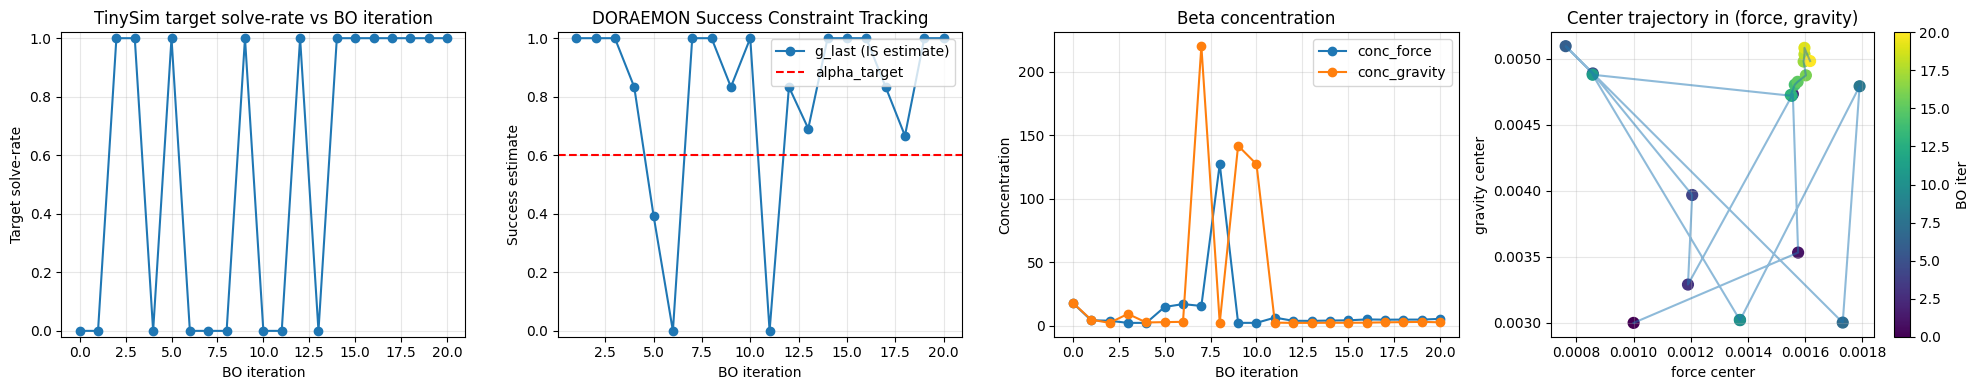

In [49]:
# choose which result to visualize
result = edge_result  # or prototype_result / edge_result
hist = result['history']

iters = [r['iter'] for r in hist]
fvals = [r['target_solve_rate'] for r in hist]
glast = [r['g_last'] for r in hist]
mu_f = [r['mu_force'] for r in hist]
mu_g = [r['mu_gravity'] for r in hist]
cf = [r['conc_force_end'] for r in hist]
cg = [r['conc_gravity_end'] for r in hist]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(iters, fvals, marker='o')
axes[0].set_title('TinySim target solve-rate vs BO iteration')
axes[0].set_xlabel('BO iteration')
axes[0].set_ylabel('Target solve-rate')
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, glast, marker='o', label='g_last (IS estimate)')
axes[1].axhline(ALPHA_TARGET, color='r', linestyle='--', label='alpha_target')
axes[1].set_title('DORAEMON Success Constraint Tracking')
axes[1].set_xlabel('BO iteration')
axes[1].set_ylabel('Success estimate')
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(iters, cf, marker='o', label='conc_force')
axes[2].plot(iters, cg, marker='o', label='conc_gravity')
axes[2].set_title('Beta concentration')
axes[2].set_xlabel('BO iteration')
axes[2].set_ylabel('Concentration')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

sc = axes[3].scatter(mu_f, mu_g, c=iters, cmap='viridis', s=60)
axes[3].plot(mu_f, mu_g, alpha=0.5)
axes[3].set_title('Center trajectory in (force, gravity)')
axes[3].set_xlabel('force center')
axes[3].set_ylabel('gravity center')
axes[3].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[3], label='BO iter')

plt.tight_layout()
plt.show()



## 11) Playback Best Policy in TinySim (Inline Animation)

In [51]:
def render_tinysim_state_frame(position, min_position=-1.2, max_position=0.6, goal_position=0.5):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
    x = np.linspace(min_position, max_position, 500)
    y = np.sin(3 * x)
    car_y = np.sin(3 * position)

    ax.plot(x, y, color='black', linewidth=2)
    ax.scatter([position], [car_y], s=200, c='crimson', zorder=5)

    gx = goal_position
    gy = np.sin(3 * gx)
    ax.plot([gx, gx], [gy, gy + 0.2], color='black', linewidth=2)
    ax.fill([gx, gx + 0.06, gx], [gy + 0.2, gy + 0.17, gy + 0.14], color='gold')

    ax.set_xlim(min_position - 0.05, max_position + 0.05)
    ax.set_ylim(-1.25, 1.25)
    ax.set_title('Best BO+DORAEMON Policy in TinySim')
    ax.set_xlabel('Position')
    ax.set_ylabel('Height')
    ax.grid(alpha=0.3)

    from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
    canvas = FigureCanvas(fig)
    canvas.draw()
    frame = np.asarray(canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return frame


def load_agent_from_checkpoint(path: str | Path, device: str = DEVICE) -> DQNAgent:
    payload = torch.load(str(path), map_location=device)
    agent = make_agent_from_hparams(payload.get('hparams'), device=device)
    agent.load_payload(payload)
    return agent


def record_best_policy_frames(agent: DQNAgent, target_params: dict, max_steps: int = 200):
    sim_env = MountainCarEnv()
    sim_env.force = float(target_params['force'])
    sim_env.gravity = float(target_params['gravity'])

    state = sim_env.reset()
    obs = np.array([state['position'], state['velocity']], dtype=np.float32)

    frames = [
        render_tinysim_state_frame(
            position=float(state['position']),
            min_position=sim_env.min_position,
            max_position=sim_env.max_position,
            goal_position=sim_env.goal_position,
        )
    ]

    done = bool(state['done'])
    steps = 0

    while (not done) and steps < max_steps:
        a = agent.act(obs, training=False)
        state = sim_env.step(a)
        obs = np.array([state['position'], state['velocity']], dtype=np.float32)
        done = bool(state['done'])
        steps += 1

        frames.append(
            render_tinysim_state_frame(
                position=float(state['position']),
                min_position=sim_env.min_position,
                max_position=sim_env.max_position,
                goal_position=sim_env.goal_position,
            )
        )

    summary = {
        'solved': bool(done),
        'steps': int(steps),
        'final_position': float(state['position']),
        'n_frames': len(frames),
    }
    return frames, summary


best_agent = load_agent_from_checkpoint(result['best_checkpoint'], device=DEVICE)
frames, summary = record_best_policy_frames(best_agent, target_params=TARGET_PARAMS, max_steps=TAU_STEPS)

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=25, blit=True)
plt.close(fig)

print(summary)
HTML(ani.to_jshtml())


{'solved': True, 'steps': 149, 'final_position': 0.5019665971449729, 'n_frames': 150}
